In [1]:
import rasterio
import xarray as xr
import rioxarray
import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.autonotebook import tqdm
from itertools import product

# Dask *must* run on a local cluster so that we have shared
# memory across worker threads. Otherwise we get bottlenecked
# repeatedly reading the survey/damage datasets.
from dask.distributed import LocalCluster

from const import HOST_DCA_CODES

/tmp/ipykernel_212/2744159632.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Read data

In [2]:
template_ds = xr.open_zarr("../data_working/treemap2016_hostba_hydro.zarr/")

In [3]:
survey = gpd.read_file("../data_working/survey_merged.gdb/", layer="merged").groupby("SURVEY_YEAR")
damage = gpd.read_file("../data_working/damage_merged.gdb/", layer="merged")
damage = damage[damage.DCA_CODE.isin(HOST_DCA_CODES.values())].groupby(["SURVEY_YEAR", "DCA_CODE"])

/srv/conda/envs/notebook/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


## Define rasterization transform

We have 3 km output pixels and 100 m fine rasterization pixels. This implies a "sharpening factor" of 30, or that there are 30^2=900 fine pixels in each coarse pixel. This makes the effective "damage resolution" of each coarse pixel 1/900.

In [4]:
fine_raster_res = 100 # m
coarse_transform = template_ds.rio.transform(recalc=True)
fine_transform = rasterio.transform.Affine(
    a=fine_raster_res,
    b=coarse_transform.b,
    c=coarse_transform.c,
    d=coarse_transform.d,
    e=-fine_raster_res,
    f=coarse_transform.f
)
fine_transform

Affine(100.0, 0.0, -2362845.0,
       0.0, -100.0, 3180555.0)

In [5]:
sharpen_factor = int(coarse_transform.a // fine_raster_res)
out_shape = (template_ds.sizes["y"] * sharpen_factor, template_ds.sizes["x"] * sharpen_factor)

## Rasterization

We have to do this for each combination of survey year and damage agent. We can parallelize this so long as we send the *filtered* survey/damage tables to the dask worker. Otherwise there is way too much overhead serializing.

In [6]:
def rasterize_survey_year(survey: gpd.GeoDataFrame, damage: gpd.GeoDataFrame, year: int, dca_name: str) -> xr.DataArray:
    out_arr = np.zeros(out_shape) * np.nan

    rasterio.features.rasterize(
        survey.geometry,
        out=out_arr,
        default_value=0,
        transform=fine_transform
    )

    rasterio.features.rasterize(
        zip(damage.geometry, damage.SEVERITY),
        out=out_arr,
        transform=fine_transform
    )

    out_coarse = xr.DataArray(
        data=out_arr,
        dims=("y", "x")
    )\
        .coarsen(x=sharpen_factor, y=sharpen_factor)\
        .mean()\
        .assign_coords(
            x=template_ds.x,
            y=template_ds.y
        ).expand_dims(
            time=pd.date_range(str(year), periods=1, freq="YS"),
            var=[f"{dca_name}_mort"]
        )

    return out_coarse

In [7]:
years_to_process = list(range(1999, 2024))
print(years_to_process)

[1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [8]:
dca_names = HOST_DCA_CODES.keys()
print(dca_names)

dict_keys(['mtn_pb', 'fir_eng', 'pin_ips', 'spr_bet', 'west_pb', 'west_bb', 'doug_fb', 'jeff_pb'])


In [9]:
year_dca_prod = list(product(years_to_process, dca_names))

This is an embarassingly parallel problem, but I could not find an approach to rasterization that didn't eat a crazy amount of memory. I wager it would take me more than 40 minutes to find a good approach, so we stay with the 40-minute single-threaded result instead.

Rasterization is definitely the bottleneck, as opposed to subsetting the survey/damage datasets. There was very little speedup when doing `get_group` instead of doing a filter.

In [14]:
results = []

for year, dca in tqdm(year_dca_prod[50:60]):
    dca_code = HOST_DCA_CODES[dca]
    try:
        survey_subset = survey.get_group(year)
        damage_subset = damage.get_group((year, dca_code))
    except KeyError:
        print(f"DCA {dca} ({year}) not found!")
        continue
        
    results.append(
        rasterize_survey_year(survey_subset, damage_subset, year, dca)
    )

  0%|          | 0/10 [00:00<?, ?it/s]

In [15]:
results[0]

<xarray.DataArray (time: 1, var: 1, y: 750, x: 600)> Size: 4MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * time         (time) datetime64[ns] 8B 2005-01-01
  * var          (var) object 8B 'pin_ips_mort'
    spatial_ref  int64 8B 0
  * x            (x) float64 5kB -2.361e+06 -2.358e+06 ... -5.673e+05 -5.643e+05
  * y            (y) float64 6kB 3.179e+06 3.176e+06 ... 9.351e+05 9.321e+05

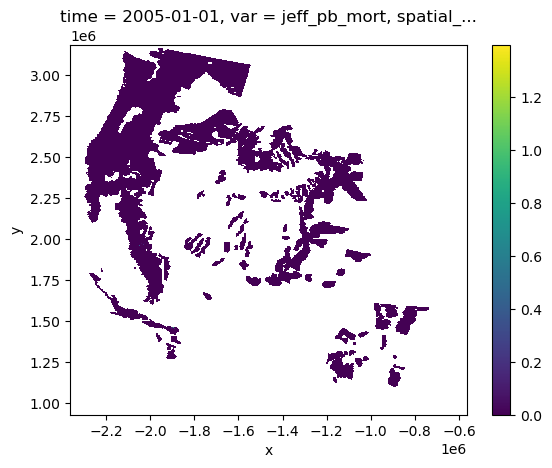

In [16]:
results[5].squeeze().plot()

In [21]:
combin = xr.combine_by_coords(results).transpose("y", "x", "time", "var")

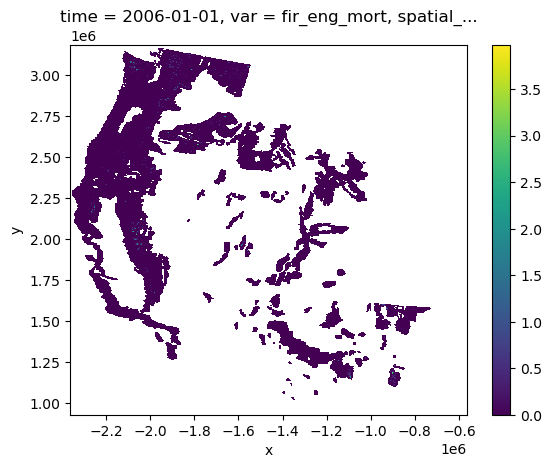

In [22]:
combin.isel(time=1, var=1).plot()

In [ ]:
damage_arr = xr.combine_by_coords(results).transpose("y", "x", "time", "var")

In [ ]:
damage_arr.to_zarr("../data_working/ads_damage.zarr")